# Simulating Heat Diffusion to Cook a Chicken with Numba and CUDA

In this notebook, we will simulate the 2D heat diffusion process to model how heat propagates through a chicken as it cooks in the oven.

To simplify the problem, we represent the chicken as a 2D grid image where each pixel corresponds to a point within the chicken.

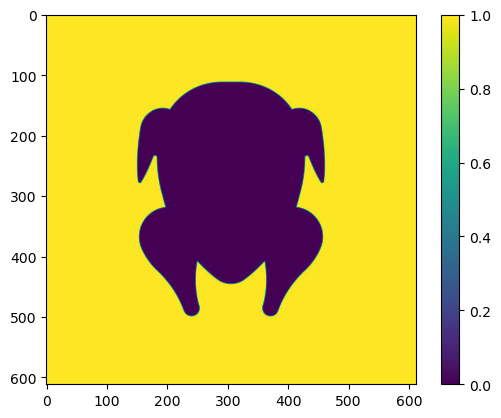

In [1]:
import numpy as np
from numba import cuda, njit, prange
import matplotlib.pyplot as plt

# Load the 2D image representation of the chicken
image = plt.imread('chicken.png')
height, width = image.shape

# Display the 2D chicken image
plt.imshow(image)
plt.colorbar()
plt.show();

## Physical Model and Assumptions

To simulate heat diffusion in our 2D "chicken" grid, we make the following assumptions:

- The oven has a width of **50 cm**.  
- The oven temperature is fixed at **200°C**.  
- The chicken’s initial internal temperature is **20°C**.  
- Heat diffusion through the chicken follows the **2D heat equation**:

$$
\frac{\partial u}{\partial t} = \alpha \nabla^2 u
$$

where:
- $ u = u(x, y, t) $ is the temperature field,
- $ \alpha $ is the **thermal diffusivity** (in $ \text{m}^2/\text{s} $).

For chicken, $ \alpha$ has been measured (!) to be approximately $1.32 \times 10^{-7} \, \text{m}^2/\text{s} $, allowing us to model how heat penetrates and warms the chicken over time.

### Simulation Parameters

To simulate heat transfer over time, we'll need to update the temperature of each "pixel" representing the chicken at each time step.

- Total simulation time: 1 hour
- Time step: $\Delta t = 1 \, \text{s}$

### Discretizing the Heat Equation

The continuous heat equation can be expressed as:
$$
\frac{\partial u}{\partial t} = \alpha \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)
$$

To implement this, we discretize the equation in both time and space.

Let $u_{i,j}^{\tau}$ represent the temperature at pixel $(i, j)$ at time $\tau$. The discrete form of the equation then becomes:

$$
\frac{u_{i,j}^{\tau+1} - u_{i,j}^{\tau}}{\Delta t} = \alpha \left( \frac{u_{i+1,j}^{\tau} - 2u_{i,j}^{\tau} + u_{i-1,j}^{\tau}}{\Delta x^2} + \frac{u_{i,j+1}^{\tau} - 2u_{i,j}^{\tau} + u_{i,j-1}^{\tau}}{\Delta y^2} \right)
$$

This formulation allows us to iteratively update each pixel's temperature at every time step.

## Update Rule

To update the temperature field at the next time step $\tau+1$, we use the current state of the temperature field at time $\tau$.

Assuming that each pixel represents an equal spatial step size along both $x(i)$ and $y(j)$ axes, we set $\Delta x = \Delta y = \Delta s$.

The update rule for each pixel $(i, j)$ at time $\tau+1$ then becomes:

$$
u_{i,j}^{\tau+1} = u_{i,j}^{\tau} + \alpha \frac{\Delta t}{\Delta s^2} \left( u_{i+1,j}^{\tau} + u_{i-1,j}^{\tau} + u_{i,j+1}^{\tau} + u_{i,j-1}^{\tau} - 4u_{i,j}^{\tau} \right)
$$

This equation allows us to iteratively compute the temperature at each pixel for the next time step, based on its current state and the temperatures of its neighboring pixels.

This is finally the equation we would like to solve for all pixels of our chicken and for all timesteps.

In [ ]:
# Create a mask to identify the "chicken" pixels within the image
# Pixels with values < 0.9 are considered part of the chicken
mask = image < 0.9

# Display the mask to verify which pixels belong to the chicken
plt.imshow(mask, cmap='gray')
plt.title("Chicken Pixel Mask")
plt.axis('off')
plt.show()

In [ ]:
# Initialize the temperature field
T_oven = 200.0     # Oven temperature [°C]
T_chicken = 20.0   # Initial chicken temperature [°C]

# Initialize a 2D temperature array, defaulting to the oven temperature
T_initial = np.full((height, width), T_oven, dtype=np.float32)

# Set the temperature of the chicken pixels based on the mask
T_initial[mask] = T_chicken

# Visualize the initial temperature field
plt.imshow(T_initial, cmap='coolwarm', vmin=T_chicken, vmax=T_oven)
plt.colorbar(label="Temperature (°C)")
plt.title("Initial Temperature Field of Chicken in Oven")
plt.axis('off')
plt.show()

In [ ]:
# Simulation parameters for the heat equation
oven_width = 0.5        # Width of the oven [m]
alpha = 1.32e-7         # Thermal diffusivity of chicken [m^2/s]
dx = oven_width / width # Spatial step size [m/pixel]
dt = 1.0                # Time step [s]
time = 3600.0           # Total simulation time [s] (1 hour)
num_steps = int(time / dt)  # Number of time iterations

# Precompute constant factor for the discrete heat equation
dt_dx2 = dt / (dx ** 2)

print(f"Grid size: {height}x{width} pixels")
print(f"Spatial resolution: {dx*100:.3f} cm per pixel")
print(f"Total time steps: {num_steps:,}")

## Numba CPU implementation

Write the purely-CPU implementation of the task using Numba

In [ ]:
# Numba CPU Implementation
@njit(parallel=True)
def heat_equation_cpu(Temp, Mask, Alpha, Dt_dx2, Num_steps):
    """
    Simulates 2D heat diffusion on the CPU using Numba.
    
    Parameters
    ----------
    Temp : 2D float32 array
        Temperature field (°C)
    Mask : 2D boolean array
        True for chicken pixels
    Alpha : float
        Thermal diffusivity (m^2/s)
    Dt_dx2 : float
        Precomputed factor (Δt / Δx²)
    Num_steps : int
        Number of time steps to simulate
    
    Returns
    -------
    Temp : 2D float32 array
        Temperature field after diffusion
    """

    ...

    return Temp

In [ ]:
# Run the simulation on CPU
T_final = heat_equation_cpu(T_initial, mask, alpha, dt_dx2, num_steps)

# Visualize the final temperature field
plt.imshow(T_final, cmap='coolwarm', vmin=T_chicken, vmax=T_oven)
plt.colorbar(label="Temperature (°C)")
plt.title("Final Temperature Distribution of the Chicken After Cooking")
plt.axis('off')
plt.show()

Not a great cooking to be honest... wings and legs are overdone, but the inside is still cold.

### Optimization: In-Place Array Swapping

The basic implementation of the heat diffusion solver creates a **new copy of the temperature field** at each iteration.  
While this approach is simple and clear, it incurs a significant **memory overhead** and repeated allocations, especially for large grids and long simulation times.

A common optimization is to maintain **two arrays**:
- One representing the temperature field at the current time step (`t`)
- One representing the field at the next time step (`t+1`)

After each iteration, the two arrays are **swapped in place**, avoiding the need to allocate a new array on every loop.

This approach, often called **ping-pong buffering**, significantly reduces memory usage and improves cache efficiency.

```python
Temp_new = Temp.copy()
for _ in range(Num_steps):
    # Compute new temperatures into Temp_new
    ...
    # Swap arrays
    Temp, Temp_new = Temp_new, Temp
```

## Numba CUDA implementation

Write the equivalent implementation for the GPU using Numba and CUDA.

There are several possible implementation that could be tested.
Some of them will be particularly problematic due to the way threads in a GPU are executed.

Try to implement first the following configuration:
- Write one single CUDA kernel that performs the evolution over **all time steps**  
- Use a **2D grid** of threads per block (max dimension `(32,32)` threads per block due to HW limitation)
- Decide if (and where, if this is the case) to implement thread synchronization 

**WARNING** It's possible that in the case of naive implementations, the kernel run time exceeds 5s. This is however set as an hard limit by the Jetson Nano due to its inherent limitations, and the resulting application could thus fail with an error similar to:

```c
CudaAPIError: [702] Call to cuCtxSynchronize results in CUDA_ERROR_LAUNCH_TIMEOUT
```

Consider disabling the timeout by using the script provided under `/MCP/disable_timeout.sh`
```bash
sudo ./MCP/disable_timeout.sh
```

In [ ]:
@cuda.jit
def heat_equation_gpu(...):
    
    ...

> **Sidenote** 
> 
> The `for` loop over `Num_steps` is placed outside of the `if` conditions to ensure all threads execute the loop and synchronize consistently at each `cuda.syncthreads()` call. This setup avoids potential race conditions and ensures data integrity across threads.
> 
> However, this structure also introduces some inefficiency: threads that do not meet the conditions (i.e., threads not involved in updating "chicken" pixels) are still executing the loop without performing any meaningful computation. These threads essentially "idle" through the loop, waiting at each synchronization point.
> 
> For this naive implementation, we’ll proceed with the current configuration to ensure that synchronization is handled correctly across all threads.

In [ ]:
# Transfer data to the GPU


In [ ]:
# Configure the thread grid for CUDA kernel launch
BLOCK_SIZE = 32  
threads_per_block = (BLOCK_SIZE, BLOCK_SIZE)

# Calculate the number of blocks in each dimension
blocks_per_grid_x = ...
blocks_per_grid_y = ...
blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)

In [ ]:
# Total number of time steps for the simulation
num_steps = np.int32(time)  

# Launch the CUDA kernel
heat_equation_gpu[blocks_per_grid, threads_per_block](
    ...
)

In [ ]:
# Copy the final temperature distribution back to the host
T_final = ...

# Display the final temperature distribution
plt.imshow(T_final, cmap='coolwarm', vmin=T_chicken, vmax=T_oven)
plt.colorbar(label="Temperature (°C)")
plt.title("Final Temperature Distribution of the Chicken After Cooking (GPU)")
plt.show()

Something weird is happening with this chicken...  
It is definitely worth inspecting a bit more in detail the structures highligted in the result obtained using the GPU.

In [ ]:
# Visualize grid partitioning (thread blocks)
plt.imshow(T_final, cmap='coolwarm', vmin=T_chicken, vmax=T_oven)
ax = plt.gca()

for x in range(-1, image.shape[1], BLOCK_SIZE):
    ax.axvline(x=x, color='grey', linestyle='-', linewidth=0.5)
for y in range(-1, image.shape[0], BLOCK_SIZE):
    ax.axhline(y=y, color='grey', linestyle='-', linewidth=0.5)

plt.xlim(0, T_final.shape[0])
plt.ylim(T_final.shape[1], 0)
plt.colorbar()
plt.title("Block Partitioning of CUDA Threads")
plt.show()

In [ ]:
# Zoom into a region for inspection
T_final_zoom = T_final[BLOCK_SIZE*3:BLOCK_SIZE*3+250, BLOCK_SIZE*3:BLOCK_SIZE*3+250]

plt.imshow(T_final_zoom, cmap='coolwarm')
plt.colorbar(label="Temperature (°C)")

ax = plt.gca()
for x in range(-1, 250, BLOCK_SIZE):
    ax.axvline(x=x, color='grey', linestyle='-', linewidth=0.5)
for y in range(-1, 250, BLOCK_SIZE):
    ax.axhline(y=y, color='grey', linestyle='-', linewidth=0.5)

plt.xlim(0, T_final_zoom.shape[0])
plt.ylim(T_final_zoom.shape[1], 0)
plt.title("Zoomed-In Final Temperature Distribution with Block Boundaries")
plt.show()

## Numba CUDA Alternative Implementation

In the naive CUDA implementation, each thread processed *all time steps* within a single kernel call.  
While this approach worked conceptually, it led to a critical issue:

> The boundaries of each CUDA block effectively acted as *thermal barriers* due to limited shared synchronization scope (`cuda.syncthreads()` works only within a block).

This caused discontinuities in the temperature field at block boundaries, producing unphysical results.

### A More Realistic Alternative

To fix this, we move the **time-stepping loop** back to the **CPU (host)**, and write a **simpler CUDA kernel** that:
- Performs **only one time step** of the heat diffusion.
- Updates all pixels independently and simultaneously.
- Uses **ping-pong swapping** between two device arrays (`Temp` and `Temp_new`) after each iteration.

This method avoids inter-block synchronization issues and ensures physically correct results.

In [ ]:
# Numba CUDA kernel for a single time step
@cuda.jit
def heat_equation_gpu_1step(...):

    ...

In [ ]:
# Transfer data to GPU


In [ ]:
# Grid and block configuration
BLOCK_SIZE = 32
threads_per_block = (BLOCK_SIZE, BLOCK_SIZE)

blocks_per_grid_x = ...
blocks_per_grid_y = ...
blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)

# Time-stepping loop (executed on the host)
for step in range(num_steps):
    heat_equation_gpu_1step[blocks_per_grid, threads_per_block](
        ...
    )
    cuda.synchronize()  # Ensure GPU computation is complete before swapping
    
    # Swap arrays (ping-pong buffering)


In [ ]:
# Copy result back to the host
T_final = ...

# Display the final temperature distribution
plt.imshow(T_final, cmap='coolwarm', vmin=T_chicken, vmax=T_oven)
plt.colorbar(label="Temperature (°C)")
plt.title("Final Temperature Distribution of the Chicken After Cooking (GPU)")
plt.show()